In [1]:
import zipfile

# Extract the zip file
with zipfile.ZipFile('IMDb Movies India.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

# List files to confirm what got extracted
import os
print(os.listdir())

['.config', 'IMDb Movies India.csv', 'IMDb Movies India.csv.zip', 'sample_data']


In [2]:
import pandas as pd

# Load the dataset (using latin-1 encoding, common fix for this dataset)
df = pd.read_csv('IMDb Movies India.csv', encoding='latin-1')

# Look at the first few rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
# Check dataset size and missing values
print(df.shape)
df.isnull().sum()

(15509, 10)


,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [4]:
# Drop rows where Rating is missing (can't train without the target)
df = df.dropna(subset=['Rating'])

# Drop Duration column (too many missing values)
df = df.drop('Duration', axis=1)

# Clean Year: remove parentheses and convert to number
df['Year'] = df['Year'].str.extract('(\d+)').astype(float)

# Clean Votes: remove commas and convert to number
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Fill remaining missing values in categorical columns
df['Genre'] = df['Genre'].fillna('Unknown')
df['Director'] = df['Director'].fillna('Unknown')
df['Actor 1'] = df['Actor 1'].fillna('Unknown')
df['Actor 2'] = df['Actor 2'].fillna('Unknown')
df['Actor 3'] = df['Actor 3'].fillna('Unknown')

# Drop any remaining rows with missing Year or Votes
df = df.dropna(subset=['Year', 'Votes'])

print(df.shape)
df.isnull().sum()

(7919, 9)


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1869/2734613927.py:8: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d+)').astype(float)


,0
Name,0
Year,0
Genre,0
Rating,0
Votes,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


In [6]:
# Frequency encode high-cardinality columns
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    freq = df[col].value_counts()
    df[col + '_encoded'] = df[col].map(freq)

df.head()

,Name,Year,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_encoded,Director_encoded,Actor 1_encoded,Actor 2_encoded,Actor 3_encoded
1,#Gadhvi (He thought he was Gandhi),2019.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,1177,1,2,1,1
3,#Yaaram,2019.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,120,1,5,1,2
5,...Aur Pyaar Ho Gaya,1997.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,49,17,18,15,13
6,...Yahaan,2005.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,5,7,25,4,8
8,?: A Question Mark,2012.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,11,1,1,6,1


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Features: use the numeric/encoded columns only
X = df[['Year', 'Votes', 'Genre_encoded', 'Director_encoded',
        'Actor 1_encoded', 'Actor 2_encoded', 'Actor 3_encoded']]
y = df['Rating']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.35026457489461327
Mean Squared Error: 1.2079524582879924


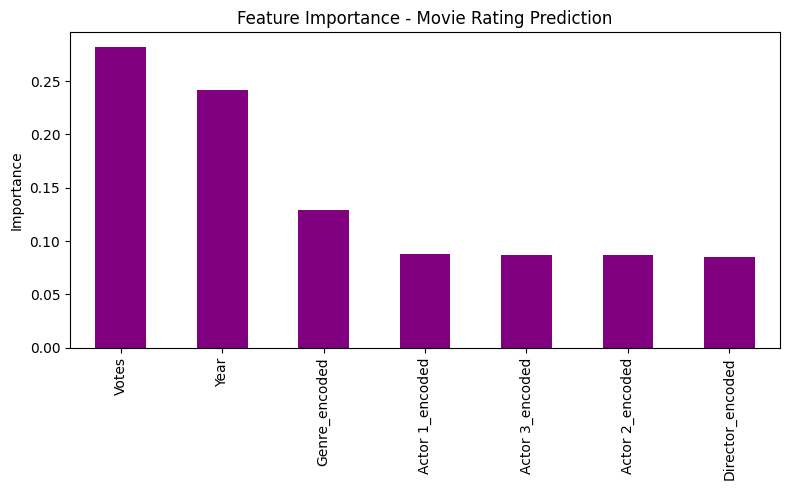

In [8]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='bar', color='purple')
plt.title('Feature Importance - Movie Rating Prediction')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('movie_feature_importance.png')
plt.show()